### 基于PCA的Iris数据集降维

#### 第1步，加载Iris特征数据并进行降维

In [1]:
# 环境配置：中文字体显示
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA # 导入PCA
from sklearn.datasets import load_iris # iris数据集
from sklearn.neighbors import KNeighborsClassifier # KNN分类模块

# 加载鸢尾花数据集
iris = load_iris()
data = iris.data # 特征数据
target = iris.target # 标签数据
print(data.shape) # 查看数据维度（150, 4）

# PCA降维
pca = PCA(n_components=2) # 利用PCA算法降成2维
new_data = pca.fit_transform(data)
print(new_data.shape) # 查看数据维度（150，2）


(150, 4)
(150, 2)


#### 第2步，数据可视化并使用KNN对比降维前后的分类准确性

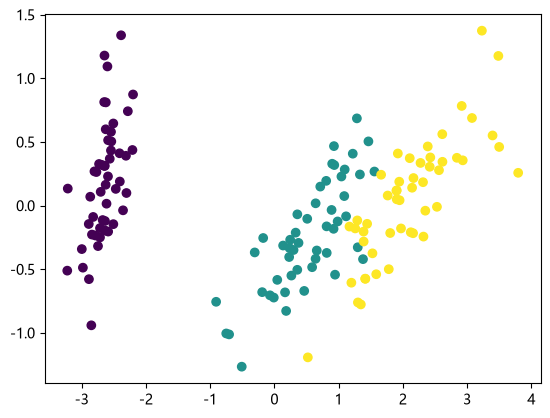

4-dims: 0.9736842105263158
2-dims: 0.9736842105263158


In [3]:
# 降维后的数据集可视化
plt.scatter(new_data[:, 0], new_data[:, 1], c=target)
plt.show()

# 使用KNN算法对比降维前后分类的准确性
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data, target, random_state=0)
model = KNeighborsClassifier().fit(X_train, y_train)
score = model.score(X_test, y_test)
print('4-dims:', score)
X_train, X_test, y_train, y_test = train_test_split(new_data, target, random_state=0)
model = KNeighborsClassifier().fit(X_train, y_train)
score = model.score(X_test, y_test)
print('2-dims:', score)


### 基于LDA的红酒数据集降维（对比PCA）

#### 第1步，加载数据分别用PCA和LDA进行降维

In [4]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA # PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis # LDA降维
from sklearn.datasets import load_wine

# 加载红酒数据集
wine = load_wine()
data = wine.data
target = wine.target
print(data.shape) # 查看数据维度

# PCA降维（无类别）
pca = PCA(n_components=2) # 利用PCA算法降成2维
data_pca = pca.fit_transform(data) # 降维转换
print('PCA:', data_pca.shape) # 查看数据维度

# LDA降维（有类别，考虑样本标签）
lda = LinearDiscriminantAnalysis(n_components=2)
data_lda = lda.fit_transform(data, target)
print('LDA:', data_lda.shape)


(178, 13)
PCA: (178, 2)
LDA: (178, 2)


#### 第2步，降维结果可视化对比

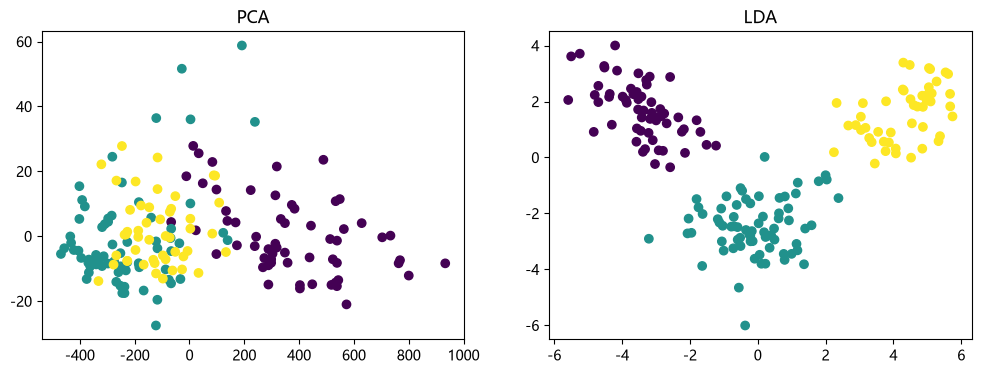

In [5]:
# LDA算法更适合有标签数据的降维
# 下面将两种方法降维后的数据进行可视化

fig = plt.figure(figsize=(12,4)) # 生成画板(12,4)

# PCA降维结果
ax1 = fig.add_subplot(1, 2, 1) # 添加子图1
ax1.scatter(data_pca[:, 0], data_pca[:, 1], c=target)
ax1.set_title('PCA')

# LDA降维结果
ax2 = fig.add_subplot(1, 2, 2) # 添加子图2
ax2.scatter(data_lda[:, 0], data_lda[:, 1], c=target)
ax2.set_title('LDA')
plt.show() # 显示图像


#### 第3步，降维前后的分类准确性对比

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression # 逻辑回归模型

# 1、使用逻辑回归模型，在降维前的数据集上训练并评估
X_train, X_test, y_train, y_test = train_test_split(data, target, random_state=0)

model = LogisticRegression(max_iter=10000).fit(X_train, y_train)
score = model.score(X_test, y_test) # 在测试集上评估分类准确性
print('4-dims:', score)

# 2、在LDA降维后的数据集上训练并评估
X_train, X_test, y_train, y_test = train_test_split(data_lda, target, random_state=0)
model = LogisticRegression(max_iter=10000).fit(X_train, y_train)
score = model.score(X_test, y_test) # 在测试集上评估分类准确性
print('2-dims(LDA):', score)


4-dims: 0.9777777777777777
2-dims(LDA): 1.0
